# Anomaly Detection With Facebook Prophet

<img src='fbprophet.png'></img>

**Purpose:**
Detect anomalies in a time series using Facebook Prophet.

**How it works:**
1. Load all historical data
2. Let Prophet learn the "normal pattern" from aLL of it
3. Ask Prophet what range it expected at each historical point
4. Flag any point that fell outside that expected range

**Dataset:**
- ETTh (Electricity Transformer Temperature)
- Target: OT (Oil Temperature) of Transformer 1
- Optional regressors: HUFL, HULL, LUFL, LULL (power loads)

## 1. Load the necessary Libraries

In [56]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from prophet import Prophet
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

| Column | Full Name | Description |
| -------- | -------- | -------- |
| date | - | Recorded timestamp |
| HUFL | High UseFul Load | Useful load at the high-voltage line |
| HULL | High UseLess Load | Useless load at the high-voltage line |
| MUFL | Middle UseFul Load | Useful load at the medium-voltage line |
| MULL | Middle UseLess Load | Useless load at the medium-voltage line |
| LUFL | Low UseFul Load | Useful load at the low-voltage line |
| LULL | Low UseLess Load | Useless load at the low-voltage line |
| OT | Oil Temperature | The prediction target |

**Where the data comes from:**
The team and Beijing Guowang Fuda Science & Technology Development Company built a real-world platform and collected 2-year data from two regions of a province of China. The dataset is from real power transformers, not synthetic.

**Why oil temperature is the target:**
Oil temperatures can reflect the condition of an electricity transformer. Predicting how the electrical transformers' oil temperature is safe avoids unnecessary waste and equipment damage from false load prediction. GitHub

**The ETT family:**
- ETTh1, ETTh2 → hourly
- The "1" and "2" refer to the two different transformer stations

## 2. Configurations

In [59]:
INPUT_FILE      = "./ETTh.csv"
TARGET_COLUMN   = 'OT'                              # what we monitor
REGRESSORS      = ['HUFL', 'HULL', 'LUFL', 'LULL']  # set to [] for univariate
INTERVAL_WIDTH  = 0.99                              # 0.95-0.99 typical for anomaly detection (for production)
USE_REGRESSORS  = True                              # toggle regressors on/off

# Output Paths
OUTPUT_DIR      = os.getcwd()
PLOT_PATH       = f"{OUTPUT_DIR}\\anomalies_plot.png"
CSV_PATH        = f"{OUTPUT_DIR}\\anomalies_detected.csv"

## 3. Load the data

In [3]:
df = pd.read_csv(INPUT_FILE)
df.head()

,date,HUFL,HULL,MUFL,MULL,LUFL,LULL,OT,HUFL.1,HULL.1,MUFL.1,MULL.1,LUFL.1,LULL.1,OT.1
0,2016-7-1 00:00,5.827,2.009,1.599,0.462,4.203,1.340,30.531000,41.130001,12.481,36.535999,9.355,4.424,1.311,38.661999
1,2016-7-1 01:00,5.693,2.076,1.492,0.426,4.142,1.371,27.787001,37.528000,10.136,33.936001,7.532,4.435,1.215,37.124001
2,2016-7-1 02:00,5.157,1.741,1.279,0.355,3.777,1.218,27.787001,37.946999,11.309,35.330002,9.007,2.100,0.000,36.465000
3,2016-7-1 03:00,5.090,1.942,1.279,0.391,3.807,1.279,25.044001,38.952000,11.895,35.543999,9.436,3.380,1.215,33.608501
4,2016-7-1 04:00,5.358,1.942,1.492,0.462,3.868,1.279,21.948000,38.113998,11.476,35.410000,9.623,2.036,0.000,31.850500


In [4]:
print(f"Dataset shape: {df.shape}")
print("="*50)
print(df.info())

Dataset shape: (17420, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17420 entries, 0 to 17419
Data columns (total 15 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    17420 non-null  object 
 1   HUFL    17420 non-null  float64
 2   HULL    17420 non-null  float64
 3   MUFL    17420 non-null  float64
 4   MULL    17420 non-null  float64
 5   LUFL    17420 non-null  float64
 6   LULL    17420 non-null  float64
 7   OT      17420 non-null  float64
 8   HUFL.1  17420 non-null  float64
 9   HULL.1  17420 non-null  float64
 10  MUFL.1  17420 non-null  float64
 11  MULL.1  17420 non-null  float64
 12  LUFL.1  17420 non-null  float64
 13  LULL.1  17420 non-null  float64
 14  OT.1    17420 non-null  float64
dtypes: float64(14), object(1)
memory usage: 2.0+ MB
None


In [5]:
# Convert date to datetime type
df["date"] = pd.to_datetime(df['date'])
print(df.date.info())

<class 'pandas.core.series.Series'>
RangeIndex: 17420 entries, 0 to 17419
Series name: date
Non-Null Count  Dtype         
--------------  -----         
17420 non-null  datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 136.2 KB
None


Keep only data of the Transformer #1, and drop Tranfoermer #2 (for now)

In [6]:
df_t1 = df.iloc[:, 0:8]
df_t1

,date,HUFL,HULL,MUFL,MULL,LUFL,LULL,OT
0,2016-07-01 00:00:00,5.827,2.009,1.599,0.462,4.203,1.340,30.531000
1,2016-07-01 01:00:00,5.693,2.076,1.492,0.426,4.142,1.371,27.787001
2,2016-07-01 02:00:00,5.157,1.741,1.279,0.355,3.777,1.218,27.787001
3,2016-07-01 03:00:00,5.090,1.942,1.279,0.391,3.807,1.279,25.044001
4,2016-07-01 04:00:00,5.358,1.942,1.492,0.462,3.868,1.279,21.948000
...,...,...,...,...,...,...,...,...
17415,2018-06-26 15:00:00,-1.674,3.550,-5.615,2.132,3.472,1.523,10.904000
17416,2018-06-26 16:00:00,-5.492,4.287,-9.132,2.274,3.533,1.675,11.044000
17417,2018-06-26 17:00:00,2.813,3.818,-0.817,2.097,3.716,1.523,10.271000
17418,2018-06-26 18:00:00,9.243,3.818,5.472,2.097,3.655,1.432,9.778000


## 4. Check Multicollinearity

In [7]:
all_regressors = ['HUFL','HULL','MUFL','MULL','LUFL','LULL']

In [14]:
X = df_t1[all_regressors]
X.head()

,HUFL,HULL,MUFL,MULL,LUFL,LULL
0,5.827,2.009,1.599,0.462,4.203,1.340
1,5.693,2.076,1.492,0.426,4.142,1.371
2,5.157,1.741,1.279,0.355,3.777,1.218
3,5.090,1.942,1.279,0.391,3.807,1.279
4,5.358,1.942,1.492,0.462,3.868,1.279


In [16]:
# Pearson Correlation
X_corr = X.corr().round(3)
X_corr

,HUFL,HULL,MUFL,MULL,LUFL,LULL
HUFL,1.000,0.115,0.987,0.066,0.291,0.024
HULL,0.115,1.000,0.069,0.930,0.259,0.378
MUFL,0.987,0.069,1.000,0.046,0.177,-0.047
MULL,0.066,0.930,0.046,1.000,0.129,0.069
LUFL,0.291,0.259,0.177,0.129,1.000,0.335
LULL,0.024,0.378,-0.047,0.069,0.335,1.000


<Axes: >

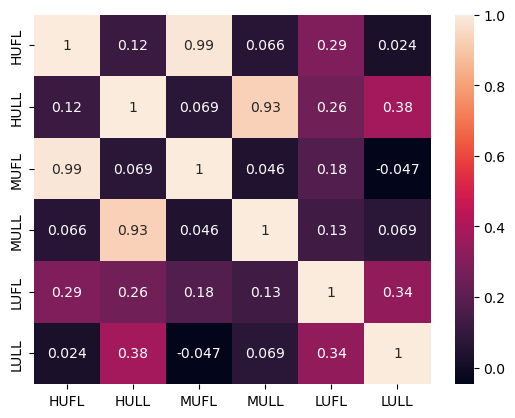

In [17]:
sns.heatmap(X_corr, annot=True)

In [18]:
for i, a in enumerate(all_regressors):
    for b in all_regressors[i+1:]:
        if abs(X_corr.loc[a, b]) > 0.8:
            print(f"{a} is collinear with {b}: {X_corr.loc[a, b]:.3f}  <-- high")

  HUFL is collinear with MUFL: 0.987  <-- high
  HULL is collinear with MULL: 0.930  <-- high


### Calculate VIF

In [19]:
X_with_constant = add_constant(X)
X_with_constant

,const,HUFL,HULL,MUFL,MULL,LUFL,LULL
0,1.0,5.827,2.009,1.599,0.462,4.203,1.340
1,1.0,5.693,2.076,1.492,0.426,4.142,1.371
2,1.0,5.157,1.741,1.279,0.355,3.777,1.218
3,1.0,5.090,1.942,1.279,0.391,3.807,1.279
4,1.0,5.358,1.942,1.492,0.462,3.868,1.279
...,...,...,...,...,...,...,...
17415,1.0,-1.674,3.550,-5.615,2.132,3.472,1.523
17416,1.0,-5.492,4.287,-9.132,2.274,3.533,1.675
17417,1.0,2.813,3.818,-0.817,2.097,3.716,1.523
17418,1.0,9.243,3.818,5.472,2.097,3.655,1.432


In [20]:
# VIF needs a constant column added (standard convention)
#df_t1_with_constant = add_constant(df_t1)
vif_data = pd.DataFrame({
    'feature': X.columns,
    'VIF': [variance_inflation_factor(X_with_constant.values, i+1)
            for i in range(len(X.columns))]
})
vif_data

,feature,VIF
0,HUFL,100.420194
1,HULL,31.232431
2,MUFL,94.828331
3,MULL,26.413395
4,LUFL,2.324788
5,LULL,3.962995


In [22]:
vif_data['interpretation'] = pd.cut(
    vif_data['VIF'],
    bins=[0, 5, 10, np.inf],
    labels=['fine', 'moderate', 'severe']
)

print(vif_data.round(2).to_string(index=False))

feature    VIF interpretation
   HUFL 100.42         severe
   HULL  31.23         severe
   MUFL  94.83         severe
   MULL  26.41         severe
   LUFL   2.32           fine
   LULL   3.96           fine


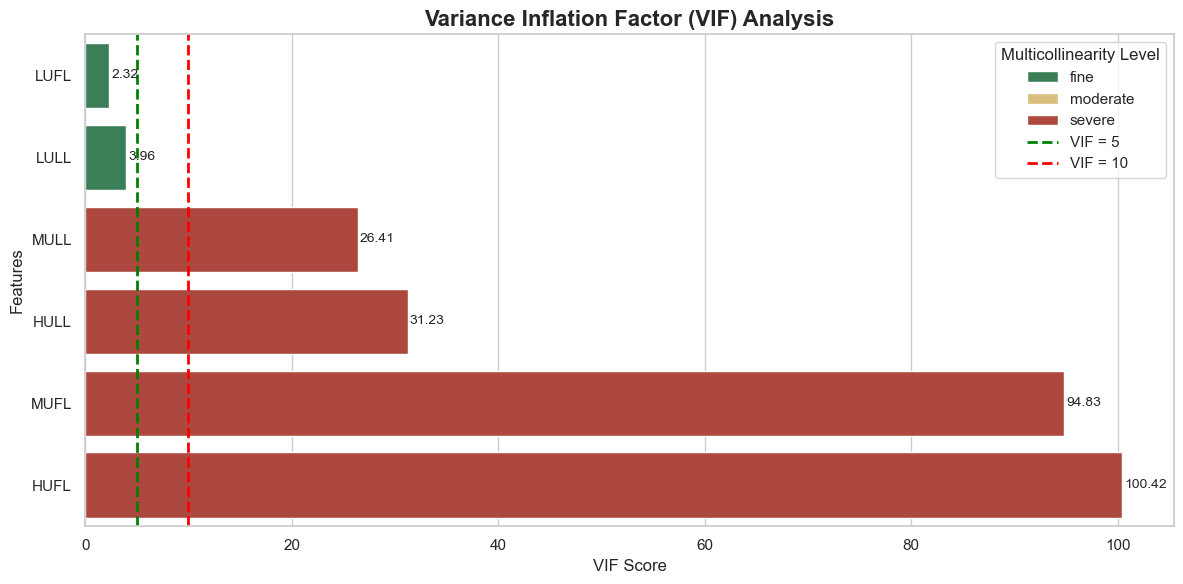

In [25]:
# Sort by VIF in ascending order 
vif_data = vif_data.sort_values('VIF', ascending=True)

sns.set_theme(style="whitegrid")

plt.figure(figsize=(12, 6))

palette = {
    'fine': '#2E8B57',       
    'moderate': '#E9C46A',  
    'severe': '#C0392B'     
}


ax = sns.barplot(
    data=vif_data,
    x='VIF',
    y='feature',
    hue='interpretation',
    palette=palette
)

# Threshold lines
plt.axvline(5, color='green', linestyle='--', linewidth=2, label='VIF = 5')
plt.axvline(10, color='red', linestyle='--', linewidth=2, label='VIF = 10')


for i, v in enumerate(vif_data['VIF']):
    ax.text(v + 0.2, i, f"{v:.2f}", va='center', fontsize=10)

plt.title(
    'Variance Inflation Factor (VIF) Analysis',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('VIF Score', fontsize=12)
plt.ylabel('Features', fontsize=12)

plt.legend(title='Multicollinearity Level')

plt.tight_layout()

plt.show()

In [23]:
REDUCED = ['HUFL', 'HULL', 'LUFL', 'LULL']

X_red = df_t1[REDUCED]
X_red_const = add_constant(X_red)
vif_reduced = pd.DataFrame({
    'feature': X_red.columns,
    'VIF': [variance_inflation_factor(X_red_const.values, i+1)
            for i in range(len(X_red.columns))]
})

feature  VIF
   HUFL 1.11
   HULL 1.20
   LUFL 1.26
   LULL 1.27


In [27]:
vif_reduced['interpretation'] = pd.cut(
    vif_reduced['VIF'],
    bins=[0, 5, 10, np.inf],
    labels=['fine', 'moderate', 'severe']
)

print(vif_reduced.round(2).to_string(index=False))

feature  VIF interpretation
   HUFL 1.11           fine
   HULL 1.20           fine
   LUFL 1.26           fine
   LULL 1.27           fine


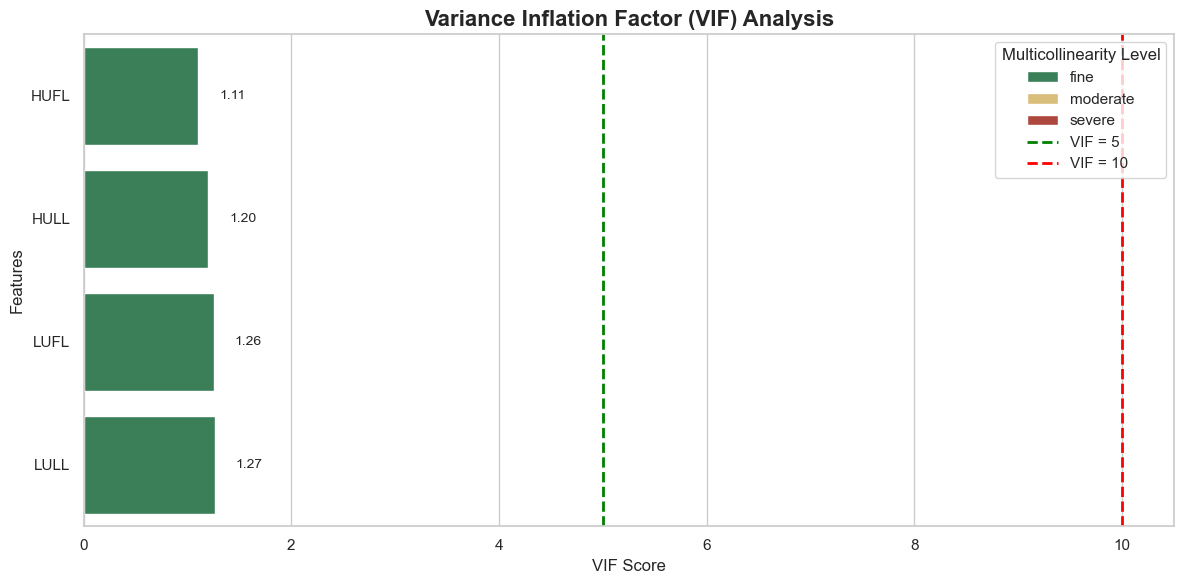

In [28]:
# Sort by VIF in ascending order 
vif_reduced = vif_reduced.sort_values('VIF', ascending=True)

sns.set_theme(style="whitegrid")

plt.figure(figsize=(12, 6))

palette = {
    'fine': '#2E8B57',       
    'moderate': '#E9C46A',  
    'severe': '#C0392B'     
}


ax = sns.barplot(
    data=vif_reduced,
    x='VIF',
    y='feature',
    hue='interpretation',
    palette=palette
)

# Threshold lines
plt.axvline(5, color='green', linestyle='--', linewidth=2, label='VIF = 5')
plt.axvline(10, color='red', linestyle='--', linewidth=2, label='VIF = 10')


for i, v in enumerate(vif_reduced['VIF']):
    ax.text(v + 0.2, i, f"{v:.2f}", va='center', fontsize=10)

plt.title(
    'Variance Inflation Factor (VIF) Analysis',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('VIF Score', fontsize=12)
plt.ylabel('Features', fontsize=12)

plt.legend(title='Multicollinearity Level')

plt.tight_layout()

plt.show()

**Drop Features with High Collinearity**

In [29]:
df.drop(columns=["MUFL", "MULL"], inplace=True)
df_t1.head()

,date,HUFL,HULL,MUFL,MULL,LUFL,LULL,OT
0,2016-07-01 00:00:00,5.827,2.009,1.599,0.462,4.203,1.340,30.531000
1,2016-07-01 01:00:00,5.693,2.076,1.492,0.426,4.142,1.371,27.787001
2,2016-07-01 02:00:00,5.157,1.741,1.279,0.355,3.777,1.218,27.787001
3,2016-07-01 03:00:00,5.090,1.942,1.279,0.391,3.807,1.279,25.044001
4,2016-07-01 04:00:00,5.358,1.942,1.492,0.462,3.868,1.279,21.948000


----------

## 5. Preprocessing

In [33]:
cols_to_keep = ["date", TARGET_COLUMN] + (REGRESSORS if USE_REGRESSORS else [])

# Rename the date and target columns
data = df[cols_to_keep].rename(columns = {"date": "ds", TARGET_COLUMN: "y"})

print(f"Loaded: {len(data):,} rows\n")
print(f"Time range: {data['ds'].min()} --> {data['ds'].max()}\n")
print(f"Target variable: {TARGET_COLUMN}\n")
print(f"Regressors used: {REGRESSORS if USE_REGRESSORS else 'None (univariate)'}\n")

Loaded: 17,420 rows

Time range: 2016-07-01 00:00:00 --> 2018-06-26 19:00:00

Target variable: OT

Regressors used: ['HUFL', 'HULL', 'LUFL', 'LULL']



-----------

## 6. Model Building

In [34]:
model = Prophet(
    yearly_seasonality = True,
    weekly_seasonality = True,
    daily_seasonality = True,
    interval_width = INTERVAL_WIDTH,
    changepoint_prior_scale = 0.05       # Default
)

In [35]:
if USE_REGRESSORS:
    for r in REGRESSORS:
        model.add_regressor(r)

model.fit(data)

10:05:09 - cmdstanpy - INFO - Chain [1] start processing
10:05:59 - cmdstanpy - INFO - Chain [1] done processing


### Ask Prophet what it expected at each historical point
We pass the same timestamps Prophet trained on. We're not predicting the future. we're just asking: "Given what you learned, what range did you expect at each historical hour?"

In [36]:
predictions = model.predict(data.drop(columns=['y']))
predictions

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,HUFL,HUFL_lower,HUFL_upper,HULL,...,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2016-07-01 00:00:00,14.171008,16.760619,31.283369,14.171008,14.171008,0.110306,0.110306,0.110306,-0.084158,...,-0.037542,-0.037542,-0.037542,9.694057,9.694057,9.694057,0.0,0.0,0.0,23.944875
1,2016-07-01 01:00:00,14.192607,16.993581,30.608113,14.192607,14.192607,0.119853,0.119853,0.119853,-0.059983,...,-0.037820,-0.037820,-0.037820,9.703112,9.703112,9.703112,0.0,0.0,0.0,23.840709
2,2016-07-01 02:00:00,14.214206,16.793062,30.286670,14.214206,14.214206,0.158044,0.158044,0.158044,-0.180857,...,-0.038838,-0.038838,-0.038838,9.712180,9.712180,9.712180,0.0,0.0,0.0,23.577074
3,2016-07-01 03:00:00,14.235805,16.209691,31.188921,14.235805,14.235805,0.162817,0.162817,0.162817,-0.108333,...,-0.040514,-0.040514,-0.040514,9.721260,9.721260,9.721260,0.0,0.0,0.0,23.665810
4,2016-07-01 04:00:00,14.257404,16.818430,30.484981,14.257404,14.257404,0.143722,0.143722,0.143722,-0.108333,...,-0.042760,-0.042760,-0.042760,9.730352,9.730352,9.730352,0.0,0.0,0.0,23.611772
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17415,2018-06-26 15:00:00,-0.352265,3.568424,17.195695,-0.352265,-0.352265,0.644755,0.644755,0.644755,0.471862,...,-0.172517,-0.172517,-0.172517,8.751786,8.751786,8.751786,0.0,0.0,0.0,10.816825
17416,2018-06-26 16:00:00,-0.354924,4.739097,19.434828,-0.354924,-0.354924,0.916790,0.916790,0.916790,0.737785,...,-0.191697,-0.191697,-0.191697,8.758634,8.758634,8.758634,0.0,0.0,0.0,11.702219
17417,2018-06-26 17:00:00,-0.357584,4.219816,18.103220,-0.357584,-0.357584,0.325055,0.325055,0.325055,0.568562,...,-0.210596,-0.210596,-0.210596,8.765506,8.765506,8.765506,0.0,0.0,0.0,10.952023
17418,2018-06-26 18:00:00,-0.360243,2.995366,17.307022,-0.360243,-0.360243,-0.133086,-0.133086,-0.133086,0.568562,...,-0.229121,-0.229121,-0.229121,8.772402,8.772402,8.772402,0.0,0.0,0.0,10.270408


In [37]:
# Merge actual values back with predicted range
results = data[['ds', 'y']].merge(
    predictions[['ds', 'yhat', 'yhat_lower', 'yhat_upper']],
    on='ds'
)

results.head()

,ds,y,yhat,yhat_lower,yhat_upper
0,2016-07-01 00:00:00,30.531000,23.944875,16.760619,31.283369
1,2016-07-01 01:00:00,27.787001,23.840709,16.993581,30.608113
2,2016-07-01 02:00:00,27.787001,23.577074,16.793062,30.286670
3,2016-07-01 03:00:00,25.044001,23.665810,16.209691,31.188921
4,2016-07-01 04:00:00,21.948000,23.611772,16.818430,30.484981


------

## 7. Flag anomalies

An anomaly is simply a value that falls outside the confidence band. 

`interval_width=0.99` means we expect 99% of normal points to fall inside this band, so anything outside is unusual.

In [39]:
results['is_anomaly'] = (
    (results['y'] > results['yhat_upper']) |   
    (results['y'] < results['yhat_lower'])     
).astype(int)

results.head()

,ds,y,yhat,yhat_lower,yhat_upper,is_anomaly
0,2016-07-01 00:00:00,30.531000,23.944875,16.760619,31.283369,0
1,2016-07-01 01:00:00,27.787001,23.840709,16.993581,30.608113,0
2,2016-07-01 02:00:00,27.787001,23.577074,16.793062,30.286670,0
3,2016-07-01 03:00:00,25.044001,23.665810,16.209691,31.188921,0
4,2016-07-01 04:00:00,21.948000,23.611772,16.818430,30.484981,0


In [40]:
# Classify type (spike vs drop) and compute severity score
def classify(row):
    if row['y'] > row['yhat_upper']:
        return 'spike'
    if row['y'] < row['yhat_lower']:
        return 'drop'
    return 'normal'

results['anomaly_type'] = results.apply(classify, axis=1)

results.head()

,ds,y,yhat,yhat_lower,yhat_upper,is_anomaly,anomaly_type
0,2016-07-01 00:00:00,30.531000,23.944875,16.760619,31.283369,0,normal
1,2016-07-01 01:00:00,27.787001,23.840709,16.993581,30.608113,0,normal
2,2016-07-01 02:00:00,27.787001,23.577074,16.793062,30.286670,0,normal
3,2016-07-01 03:00:00,25.044001,23.665810,16.209691,31.188921,0,normal
4,2016-07-01 04:00:00,21.948000,23.611772,16.818430,30.484981,0,normal


In [41]:
# Severity = how far outside the band
upper_half = (results['yhat_upper'] - results['yhat']).clip(lower=0.01)
lower_half = (results['yhat'] - results['yhat_lower']).clip(lower=0.01)

results['severity'] = np.where(
    results['anomaly_type'] == 'spike',
    (results['y'] - results['yhat_upper']) / upper_half,
    np.where(
        results['anomaly_type'] == 'drop',
        (results['yhat_lower'] - results['y']) / lower_half,
        0
    )
).round(3)

results.head()

,ds,y,yhat,yhat_lower,yhat_upper,is_anomaly,anomaly_type,severity
0,2016-07-01 00:00:00,30.531000,23.944875,16.760619,31.283369,0,normal,0.0
1,2016-07-01 01:00:00,27.787001,23.840709,16.993581,30.608113,0,normal,0.0
2,2016-07-01 02:00:00,27.787001,23.577074,16.793062,30.286670,0,normal,0.0
3,2016-07-01 03:00:00,25.044001,23.665810,16.209691,31.188921,0,normal,0.0
4,2016-07-01 04:00:00,21.948000,23.611772,16.818430,30.484981,0,normal,0.0


In [42]:
# Summary
n_total = len(results)
n_anom  = results['is_anomaly'].sum()
n_spikes = (results['anomaly_type'] == 'spike').sum()
n_drops = (results['anomaly_type'] == 'drop').sum()

print(f"Total observations: {n_total:,}")
print(f"Anomalies detected: {n_anom:,}  ({n_anom/n_total*100:.2f}%)")
print(f"Spikes: {n_spikes:,}")
print(f"Drops: {n_drops:,}\n")

Total observations: 17,420
Anomalies detected: 344  (1.97%)
Spikes: 69
Drops: 275



In [44]:
top10 = results[results['is_anomaly'] == 1].nlargest(10, 'severity')[
    ['ds', 'y', 'yhat', 'yhat_lower', 'yhat_upper', 'anomaly_type', 'severity']
]

top10.columns = ['timestamp', 'actual', 'expected', 'lower', 'upper', 'type', 'severity']

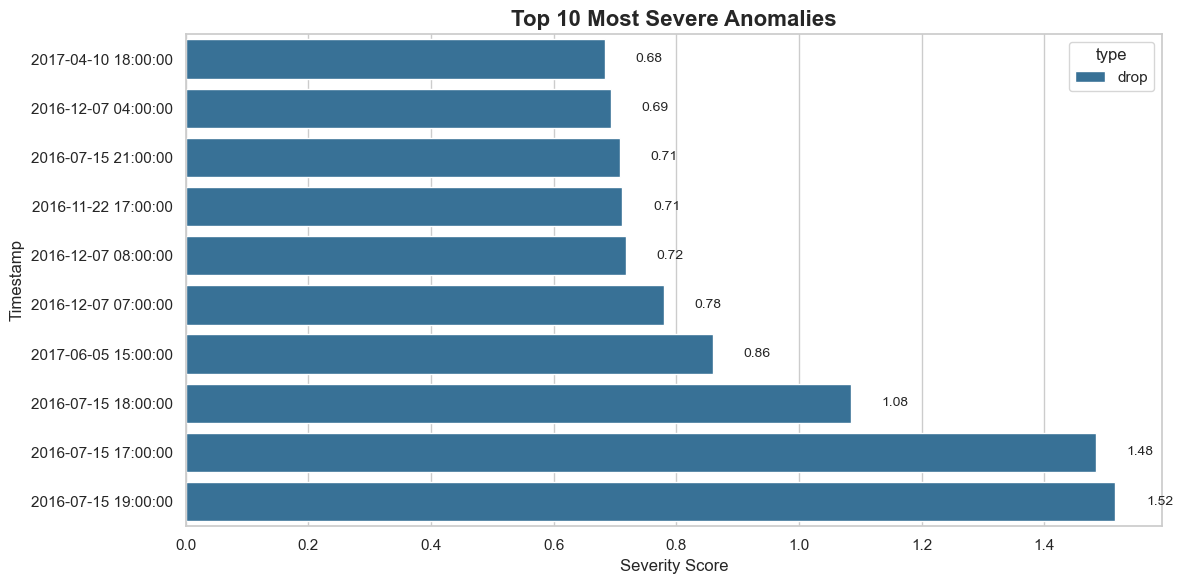

In [45]:
sns.set_theme(style="whitegrid")

# Sort by severity
top10 = top10.sort_values('severity', ascending=True)


plt.figure(figsize=(12, 6))


palette = {
    'spike': '#C0392B',   
    'drop': '#2874A6'     
}

# Horizontal barplot
ax = sns.barplot(
    data=top10,
    x='severity',
    y='timestamp',
    hue='type',
    palette=palette
)


for i, v in enumerate(top10['severity']):
    ax.text(v + 0.05, i, f"{v:.2f}", va='center', fontsize=10)


plt.title(
    'Top 10 Most Severe Anomalies',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Severity Score', fontsize=12)
plt.ylabel('Timestamp', fontsize=12)

plt.tight_layout()

plt.show()

## Save Anomalies

In [61]:
anomalies_only = results[results['is_anomaly'] == 1][
    ['ds', 'y', 'yhat', 'yhat_lower', 'yhat_upper', 'anomaly_type', 'severity']
].copy()

anomalies_only.columns = [
    'timestamp', 'actual_value', 'expected_value',
    'lower_bound', 'upper_bound', 'type', 'severity_score'
]

anomalies_only = anomalies_only.sort_values('severity_score', ascending=False)

anomalies_only.to_csv(CSV_PATH, index=False)

print(f"{len(anomalies_only)} anomalies")

344 anomalies


## Visualization

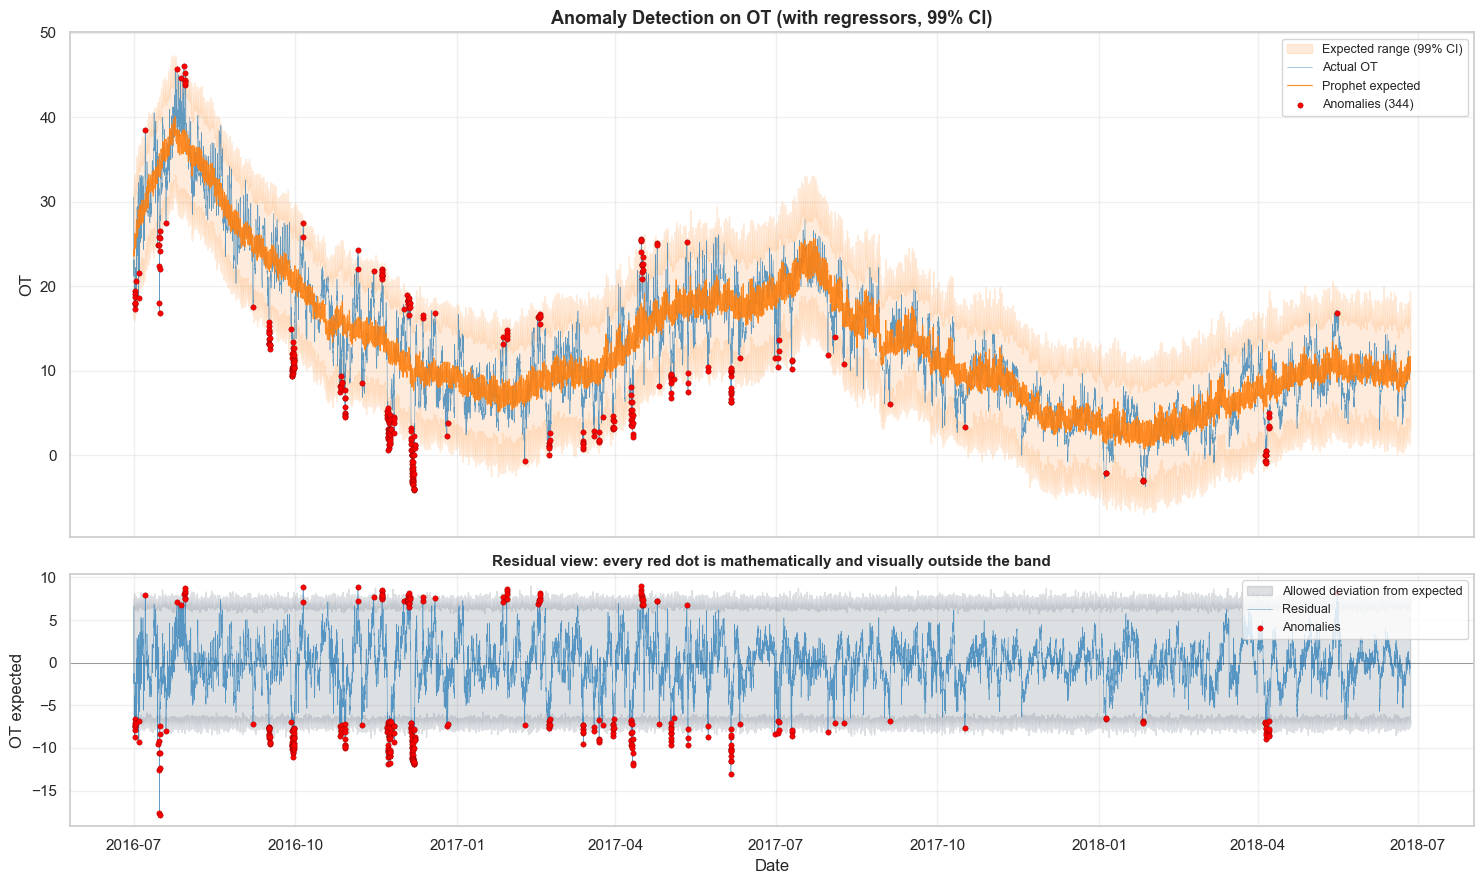

In [75]:
results['residual'] = results['y'] - results['yhat']
 
# Upper threshold = how far above expected the band reaches
# Lower threshold = how far below expected the band reaches 
results['upper_threshold'] = results['yhat_upper'] - results['yhat']
results['lower_threshold'] = results['yhat_lower'] - results['yhat']
 

fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, figsize=(15, 9), sharex=True,
    gridspec_kw={'height_ratios': [2, 1]}
)
 

ax_top.fill_between(
    results['ds'], results['yhat_lower'], results['yhat_upper'],
    color='#ff7f0e', alpha=0.15,
    label=f'Expected range ({int(INTERVAL_WIDTH*100)}% CI)'
)

ax_top.plot(results['ds'], results['y'], color='#1f77b4',
            linewidth=0.4, alpha=0.7, label=f'Actual {TARGET_COLUMN}')

ax_top.plot(results['ds'], results['yhat'], color='#ff7f0e',
            linewidth=0.8, alpha=0.9, label='Prophet expected')


anom_rows = results[results['is_anomaly'] == 1]

ax_top.scatter(anom_rows['ds'], anom_rows['y'],
               s=15, color='red', edgecolor='darkred', linewidth=0.3,
               zorder=5, label=f'Anomalies ({len(anom_rows)})')
 
ax_top.set_title(
    f'Anomaly Detection on {TARGET_COLUMN} '
    f'({"with regressors" if USE_REGRESSORS else "univariate"}, '
    f'{int(INTERVAL_WIDTH*100)}% CI)',
    fontsize=13, fontweight='bold'
)
ax_top.set_ylabel(TARGET_COLUMN)
ax_top.legend(loc='upper right', fontsize=9)
ax_top.grid(alpha=0.3)


# Residual View
 
# Plot the per-point thresholds as a band
ax_bot.fill_between(
    results['ds'], results['lower_threshold'], results['upper_threshold'],
    color='#475569', alpha=0.18, label='Allowed deviation from expected'
)
 
# Plot residuals as a thin line
ax_bot.plot(results['ds'], results['residual'], color='#1f77b4',
            linewidth=0.4, alpha=0.7, label='Residual')
 
# Zero line where actual equals expected
ax_bot.axhline(0, color='black', linewidth=0.5, alpha=0.5)
 
# Anomalies plot in residualL space, so they must be outside the band
ax_bot.scatter(
    anom_rows['ds'],
    anom_rows['y'] - anom_rows['yhat'],   # residual of each anomaly
    s=15, color='red', edgecolor='darkred', linewidth=0.3,
    zorder=5, label='Anomalies'
)
 
ax_bot.set_title(
    'Residual view: every red dot is mathematically and visually outside the band',
    fontsize=11, fontweight='bold'
)
ax_bot.set_ylabel(f'{TARGET_COLUMN} expected')
ax_bot.set_xlabel('Date')
ax_bot.legend(loc='upper right', fontsize=9)
ax_bot.grid(alpha=0.3)
ax_bot.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
 
plt.tight_layout()
plt.savefig(PLOT_PATH, dpi=120, bbox_inches='tight')